<a href="https://colab.research.google.com/github/ellen-ying/NMA2026/blob/main/W2D2_SignalProcessing/W2D2_Tutorial1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 1: Sampling

**Week 2, Day 2: Time series and signal processing**

**By Neuromatch Academy (community contribution)**

**Content Creators:** Muthu Jeyanthi Prakash, Sricharan Sunder

**Content Reviewers:** Andreas Neef, Richard Gao

**Production editors:** Konstantine Tsafatinos

---

# Tutorial Objectives

*Estimated timing of tutorial: 45 min*

This tutorial builds the foundation for working with digital signals. Virtually any signal you will ever work with in a computer will be presented to you in digital form. This happens through sampling.

**Sampling** is the discretization of a continuous signal by measuring or recording the signal only at fixed moments in time and discarding everything between. When we work with the sampled signal, we also interpret it at the time points between the samples.

**Signal reconstruction** is the opposite process that turns a finite sequence of samples into an estimate of a continuous signal.


### Overview of the Tutorial section:

- Introduction of our workhorse for today: the sine wave
- Sample a continuous signal at different rates
- Implement and compare strategies to visualize and reconstruct: lollipop plot, linear interpolation, and sinc convolution
- Understand the Nyquist–Shannon theorem from first principles and verify it numerically
- Identify aliasing and predict the apparent frequency of an undersampled signal
---

In [ ]:
# @title Tutorial slides
# @markdown These are the slides for all videos in this tutorial.
from IPython.display import IFrame
link_id = "72y8w"
print(f"If you want to download the slides: https://osf.io/download/{link_id}/")
IFrame(src=f"https://mfr.ca-1.osf.io/render?url=https://osf.io/{link_id}/?direct%26mode=render%26action=download%26mode=render", width=854, height=480)

# Setup

In [1]:
# @title Install and import feedback gadget
!pip3 install vibecheck datatops --quiet
from vibecheck import DatatopsContentReviewContainer
def content_review(notebook_section: str):
    return DatatopsContentReviewContainer(
        "",
        notebook_section,
        {
            "url": "https://pmyvdlilci.execute-api.us-east-1.amazonaws.com/klab",
            "name": "neuromatch_cn",
            "user_key": "y1x3mpx5",
        },
    ).render()
feedback_prefix = "W2D2_T1"

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 30.6 MB/s eta 0:00:00


In [2]:
# @title Imports
# @hint If you get an error message on the first compile, try again, it usually works on the second attempt
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import ipywidgets as widgets
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
# @title Figure Settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

# Section 1: The Sine Wave

In this tutorial, we introduce the humble sine wave as an example signal that we want to sample. Later, we will see how sine waves can actually be used as building blocks to represent *any* signal.

A sine wave is described by three parameters:

| Parameter | Symbol | What it controls |
|-----------|--------|------------------|
| **Amplitude** | $A$ | Height of the wave (how loud / how strong) |
| **Frequency** | $f$ | How many cycles per second (measured in Hz) |
| **Phase** | $\varphi$ | Where in its cycle the wave starts (in radians) |

Together they give:

$$s(t) = A \cdot \sin(2\pi f t + \varphi)$$

In [ ]:
# @title Video 1: Overview and sine wave

from ipywidgets import widgets
from IPython.display import YouTubeVideo
from IPython.display import IFrame
from IPython.display import display


class PlayVideo(IFrame):
  def __init__(self, id, source, page=1, width=400, height=300, **kwargs):
    self.id = id
    if source == 'Bilibili':
      src = f'https://player.bilibili.com/player.html?bvid={id}&page={page}'
    elif source == 'Osf':
      src = f'https://mfr.ca-1.osf.io/render?url=https://osf.io/download/{id}/?direct%26mode=render'
    super(PlayVideo, self).__init__(src, width, height, **kwargs)


def display_videos(video_ids, W=400, H=300, fs=1):
  tab_contents = []
  for i, video_id in enumerate(video_ids):
    out = widgets.Output()
    with out:
      if video_ids[i][0] == 'Youtube':
        video = YouTubeVideo(id=video_ids[i][1], width=W,
                             height=H, fs=fs, rel=0)
        print(f'Video available at https://youtube.com/watch?v={video.id}')
      else:
        video = PlayVideo(id=video_ids[i][1], source=video_ids[i][0], width=W,
                          height=H, fs=fs, autoplay=False)
        if video_ids[i][0] == 'Bilibili':
          print(f'Video available at https://www.bilibili.com/video/{video.id}')
        elif video_ids[i][0] == 'Osf':
          print(f'Video available at https://osf.io/{video.id}')
      display(video)
    tab_contents.append(out)
  return tab_contents

video_ids = [('Youtube', 'Fr5Q3VVo6OA'), ('Bilibili', 'BV1m4Mp6aEyV')]
tab_contents = display_videos(video_ids, W=854, H=480)
tabs = widgets.Tab()
tabs.children = tab_contents
for i in range(len(tab_contents)):
  tabs.set_title(i, video_ids[i][0])
display(tabs)

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Video_1_SamplingSine")

## Coding Exercise 1: Implement the sine wave

Before you play with the sliders, write the sine-wave equation yourself.

Fill in `make_sine_wave(t, A, f, phi)` below so that it returns

$$s(t) = A \cdot \sin(2\pi f t + \varphi)$$

evaluated at every time sample in `t`.

The widget further down the page calls this function. Once you implement the sine function correctly, the sliders will spring to life.

In [4]:
def make_sine_wave(t, A, f, phi):
    """Generate a sine wave.

    Args:
        t (ndarray): time samples in seconds, shape (n_samples,)
        A (float):   amplitude
        f (float):   frequency in Hz
        phi (float): phase offset in radians

    Returns:
        ndarray: s(t) = A * sin(2π f t + φ), shape (n_samples,)
    """

    # Compute the sine wave  s(t) = A · sin(2π f t + φ)
    s = A * np.sin(2 * np.pi * f * t + phi)

    return s

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content/tree/main/tutorials/W2D2_SignalProcessing/solutions/W2D2_Tutorial1_Solution_60e0f477.py)

## Interactive Demo 1: Properties of a sine wave

The goal of the widget is to find the correct parameters to redraw a **mystery signal** (gray dashed line).

Watch how each slider changes the shape of your signal (blue), and try to drive the **MSE as close to 0 as possible** to draw your reconstruction (blue)

In [5]:
# @title Match the target sine wave

def build_sine_demo():
    # ── Instructor config ──
    A_TRUE, F_TRUE, PHI_TRUE = 1.5, 5.0, 1.0
    DURATION, FS = 1.0, 1000
    t = np.linspace(0, DURATION, int(FS * DURATION), endpoint=False)
    y_true = A_TRUE * np.sin(2 * np.pi * F_TRUE * t + PHI_TRUE)

    amp_slider = widgets.FloatSlider(
        value=1.0, min=0.0, max=3.0, step=0.05,
        description='Amplitude (A)',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='420px')
    )

    freq_slider = widgets.FloatSlider(
        value=1.0, min=1.0, max=20.0, step=0.5,
        description='Frequency f (Hz)',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='420px')
    )

    phase_slider = widgets.FloatSlider(
        value=0.0, min=0.0, max=2 * np.pi, step=0.05,
        description='Phase φ (rad)',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='420px'),
        readout_format='.2f'
    )

    img_out = widgets.Image(format='png')


    def update(_change=None):
        A   = amp_slider.value
        f   = freq_slider.value
        phi = phase_slider.value

        y_student = make_sine_wave(t, A, f, phi)
        mse = np.mean((y_true - y_student) ** 2)

        fig, ax = plt.subplots(figsize=(9, 4))

        ax.plot(t, y_true, color='#888888', linestyle='--', linewidth=2,
                label='Target signal', alpha=0.85)
        ax.plot(t, y_student, color='#2563EB', linewidth=2,
                label=f'Your signal  (A={A:.2f}, f={f:.1f} Hz, φ={phi:.2f} rad)')

        ax.set_title('Single Sine Wave — Match the Target', fontsize=14)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude')
        ax.legend(loc='upper right', fontsize=9)
        ax.set_xlim(0, DURATION)
        ax.set_ylim(-3.5, 3.5)

        mse_color = '#16a34a' if mse < 0.01 else '#dc2626'
        ax.text(
            0.02, 0.95, f'MSE: {mse:.4f}',
            transform=ax.transAxes, fontsize=12, verticalalignment='top',
            color=mse_color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=mse_color, alpha=0.8)
        )

        fig.tight_layout()
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        img_out.value = buf.read()


    amp_slider.observe(update, names='value')
    freq_slider.observe(update, names='value')
    phase_slider.observe(update, names='value')

    ui = widgets.VBox([
        amp_slider,
        freq_slider,
        phase_slider,
        img_out
    ])

    display(ui)
    update()


build_sine_demo()

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Demo_1_SineMatch")

## Anatomy of a Sine Wave

$$\boxed{s(t) = A \cdot \sin(2\pi f t + \varphi)}$$

### Amplitude $A$
Controls the **peak value** of the wave. Doubling $A$ doubles the height without
changing the speed or timing of the oscillation. In physical systems, amplitude
often relates to energy: signal power scales as $A^2$.

### Frequency $f$
Controls how many **full cycles** occur per second (unit: Hz = cycles/second).
A higher frequency means a faster oscillation and a shorter 'period' ($T$, how long it takes to complete one cycle):

$$T = \frac{1}{f}$$

The factor $2\pi$ converts from cycles/second to **angular frequency**
$\omega = 2\pi f$ (radians/second), because one full cycle spans $2\pi$ radians, i.e., one rotation around a circle.

### Phase $\varphi$
Controls the **starting position** of the oscillation at $t = 0$ (unit: radians).
A phase of $\varphi = \pi/2$ shifts the sine into a cosine;
$\varphi = \pi$ flips it upside down.
Phase only matters *relative* to another signal.

### Key intuitions
- Moving the **amplitude slider** stretches the wave **vertically**.
- Moving the **frequency slider** compresses the wave **horizontally** (more wiggles per second).
- Moving the **phase slider** **slides** the wave left or right in time.

Try playing with the widget again with these intuitions in mind.

---

# Section 2: Sampling

*Estimated timing to here from start of tutorial: 10 min*

In [ ]:
# @title Video 2: Sampling

from ipywidgets import widgets
from IPython.display import YouTubeVideo
from IPython.display import IFrame
from IPython.display import display


class PlayVideo(IFrame):
  def __init__(self, id, source, page=1, width=400, height=300, **kwargs):
    self.id = id
    if source == 'Bilibili':
      src = f'https://player.bilibili.com/player.html?bvid={id}&page={page}'
    elif source == 'Osf':
      src = f'https://mfr.ca-1.osf.io/render?url=https://osf.io/download/{id}/?direct%26mode=render'
    super(PlayVideo, self).__init__(src, width, height, **kwargs)


def display_videos(video_ids, W=400, H=300, fs=1):
  tab_contents = []
  for i, video_id in enumerate(video_ids):
    out = widgets.Output()
    with out:
      if video_ids[i][0] == 'Youtube':
        video = YouTubeVideo(id=video_ids[i][1], width=W,
                             height=H, fs=fs, rel=0)
        print(f'Video available at https://youtube.com/watch?v={video.id}')
      else:
        video = PlayVideo(id=video_ids[i][1], source=video_ids[i][0], width=W,
                          height=H, fs=fs, autoplay=False)
        if video_ids[i][0] == 'Bilibili':
          print(f'Video available at https://www.bilibili.com/video/{video.id}')
        elif video_ids[i][0] == 'Osf':
          print(f'Video available at https://osf.io/{video.id}')
      display(video)
    tab_contents.append(out)
  return tab_contents

video_ids = [('Youtube', 'RcJ1DLtuGFE'), ('Bilibili', 'BV1HzMp6WEAR')]
tab_contents = display_videos(video_ids, W=854, H=480)
tabs = widgets.Tab()
tabs.children = tab_contents
for i in range(len(tab_contents)):
  tabs.set_title(i, video_ids[i][0])
display(tabs)

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Video_2_Sampling")

## What is Sampling?

Processes in the real world unfold in continuous time and in continuous-valued, analog variables $x(t)$. Think, for instance, of the value of a voltage at an EEG electrode: it has a magnitude, expressed as a real number with a unit, at *any* time $t$.

Nowadays, however, virtually every device captures, stores, and handles variables in a *digitized* form.
**Sampling** is the process that turns the continuous-time signal $x(t)$ into a sequence of numbers $x[t_n]$ by measuring the signal at regular time intervals.

Sampling always throws away some information, but under certain conditions, you can still reconstruct the original continuous signal perfectly.

A few definitions:

$\Delta t$ : sampling interval

$f_s=1/\Delta t$ : sampling frequency (or equivalently referred to as the sampling rate)


Mathematically, if the original signal is $x(t)$ and the sampling interval
is $\Delta t = 1/f_s$, then what your device records is:

$$x_i = x[t_i] = x(t_0 + i\cdot\Delta t), \qquad i = 0, 1, 2, \ldots$$

Practically, sampling is always accompanied by "amplitude discretization" because $x_i$ is internally represented as an integer number of bits in a computer, and thus the values live in some finite interval that is tiled by a finite number of discrete values (8 bits = 256 values; 12 bits = 4096 values). You might be familiar with this from digital images. For now, we ignore the amplitude discretization and assume that the number of bits is so high that we capture the signal amplitude without error.

**A small lie**: similarly, when we present the "original" signal in any of the widgets and exercises, we actually present a very finely sampled digital version. When you then sample with a coarser grid from the already sampled data, we refer to it as **subsampling**. The function you are asked to complete later is thus named `subsample`, but throughout the text we keep it simple and just refer to it as "sampling", pretending that the original signal is continuous-time.

---

## Coding Exercise 2: Implement sampling

Complete the function below. Given the full dense signal and a target
sampling frequency, return the times and values of the sampled points.

**Hint:** compute the step size as multiples of the much smaller original step size `round(FS_TRUE / fs)` and use
`np.arange` to pick every $k$-th index.

In [6]:
# @title True Signal Generation — run this cell

FS_TRUE   = 10_000.0   # dense axis, treated as continuous
F_SIGNAL  = 5.0        # Hz — sine wave frequency
DURATION  = 1.0        # seconds — displayed window
TOTAL_DUR = 100.0      # seconds — full context for sinc reconstruction

# ── sine signal ──────────────────────────────────────────────
_N          = int(FS_TRUE * TOTAL_DUR)
_t_total    = np.linspace(0, TOTAL_DUR, _N, endpoint=False)
_sig_sine   = np.sin(2 * np.pi * F_SIGNAL * _t_total)

_start_t    = (TOTAL_DUR - DURATION) / 2
_mask       = (_t_total >= _start_t) & (_t_total < _start_t + DURATION)
t_eval      = _t_total[_mask]          # total-time axis — used in sinc, never shifted
t_plot      = t_eval - _start_t        # 0–1 s axis — used only for plotting
sig_true    = _sig_sine[_mask]         # ground truth: same array as _sig_sine

print(f'Sine signal:      {len(sig_true)} samples in display window')

Sine signal:      10000 samples in display window


In [11]:
def subsample(t_total, sig_total, fs, phase):
    """Subsample a dense signal at a target rate.

    Parameters
    ----------
    t_total   : (N,) full time axis at FS_TRUE resolution
    sig_total : (N,) full signal
    fs        : float, target sampling frequency in Hz

    Returns
    -------
    t_samp : (M,) sample times
    y_samp : (M,) sample values
    """

    step   = max(1, int(round(FS_TRUE / fs)))
    idx    = np.arange(int(np.round(0+phase/2/np.pi*step)), len(t_total), step)
    return t_total[idx], sig_total[idx]

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content/tree/main/tutorials/W2D2_SignalProcessing/solutions/W2D2_Tutorial1_Solution_04658a3f.py)

In [12]:
t_samp, y_samp = subsample(_t_total, _sig_sine, fs=20,phase=0)
print(f'fs=20 Hz → {len(t_samp)} total samples, '
      f'step = {round(FS_TRUE/20)} samples')
assert len(t_samp) == 2000, 'Expected 2000 samples for fs=20 over 100 s'
print('Test passed ✓')

fs=20 Hz → 2000 total samples, step = 500 samples
Test passed ✓


We have 100 s of data sampled at 20 Hz from an underlying simulated ground truth signal at 10000 Hz

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Exercise_2_Sampling")

---
## Interactive Demo 2:  Visualization of sampled data

Once we have discrete samples $x[i]$, we can visualize them against the ground truth "continuous" signal. We can plot them as:

**Lollipop** : plot only the sample values as vertical stems and nowhere else. This shows exactly what was measured. Information between the samples is not considered.

**Linear interpolation** : connect adjacent samples with straight lines: Use `np.interp(t_eval, t_samp, y_samp)`.

In the demo below, you can toggle between the two visualizations, and also change the sampling frequency with the slider.

In [13]:
# @title Helper: plot_reconstruction — run this cell
def get_one_second_signal_to_visualize(t_samp, y_samp, start_t):
    """Return sample positions shifted to the 0–1 s plot axis.

    Parameters
    ----------
    t_samp  : (M,) sample times on the total-time axis
    y_samp  : (M,) sample values
    start_t : float, offset of the display window

    Returns
    -------
    t_vis : visible sample times shifted to 0–1 s
    y_vis : corresponding sample values
    """
    ##############################################################################
    in_win = (t_samp >= start_t) & (t_samp < start_t + DURATION)
    t_vis  = t_samp[in_win] - start_t
    y_vis  = y_samp[in_win]
    return t_vis, y_vis
    ##############################################################################

def subsample(t_total, sig_total, fs, phase):
    step   = max(1, int(round(FS_TRUE / fs)))
    idx    = np.arange(int(np.round(0+phase/2/np.pi*step)), len(t_total), step)
    return t_total[idx], sig_total[idx]

def plot_reconstruction(fs, mode):
    t_samp, y_samp = subsample(_t_total, _sig_sine, fs,phase=0)
    t_v, y_v       = get_one_second_signal_to_visualize(t_samp, y_samp, _start_t)

    fig, axes = plt.subplots(2, 1, figsize=(10, 6),
                             constrained_layout=True, sharex=True)
    fig.set_facecolor('white')

    # top: true + samples
    ax = axes[0]
    ax.plot(t_plot, sig_true, color='#3778bf', lw=1.8,
            alpha=0.85, label='True signal', zorder=2)
    ax.plot(t_v, y_v, 'o', color='#d62728', markersize=5.5,
            zorder=4, label=f'Samples ({len(t_v)} in window)')
    ax.set(ylabel='Amplitude', ylim=(-1.25, 1.25),
           title=f'True signal and samples  (fs = {fs} Hz)')
    ax.legend(fontsize=9, framealpha=0.9, loc='upper right')
    ax.grid(True, alpha=0.20)

    # bottom: reconstruction
    ax = axes[1]
    ax.plot(t_plot, sig_true, color='#3778bf', lw=1.4,
            alpha=0.25, label='True signal (reference)', zorder=1)

    if mode == 'lollipop':
        ax.plot(t_v, y_v, 'o', color='#d62728', markersize=5.5,
                label='Lollipop', zorder=4)
        ax.vlines(t_v, 0, y_v, color='#d62728', lw=1.3, alpha=0.75, zorder=3)

        title = 'Lollipop'

    elif mode == 'linear':

        ax.plot(t_v, y_v, '-o', color='#d62728', markersize=4, zorder=4)
        title = 'Linear - straight lines between samples'

    else:
        print(f'Unknown mode: {mode}')

    ax.set(xlabel='Time (s)', ylabel='Amplitude',
           ylim=(-1.25, 1.25), title=title)
    ax.legend(fontsize=9, framealpha=0.9, loc='upper right')
    ax.grid(True, alpha=0.20)
    plt.show()

# @markdown Execute to compare reconstruction strategies

@widgets.interact(
    fs   = widgets.IntSlider(value=15, min=5, max=60, step=1,
                             description='Sampling frequency, fs (Hz):',
                             style={'description_width': '70px'},
                             layout=widgets.Layout(width='420px')),
    mode = widgets.RadioButtons(
               options=[('Lollipop',                'lollipop'),
                        ('Straight-line connectors', 'linear'),
                        #('Sinc reconstruction',      'sinc')
                        ],
               value='lollipop',
               description='Method:',
               style={'description_width': '70px'})
)
def visualize_reconstruction(fs=15, mode='lollipop'):
    plot_reconstruction(fs=fs, mode=mode)

interactive(children=(IntSlider(value=15, description='Sampling frequency, fs (Hz):', layout=Layout(width='420…

## Think! 1: visualization (and reconstruction) strategies

- The lollipop indicates the value at each sample instant and avoids claims about the signal in between them. It is thus the most conservative representation. It does not mislead you into making unfounded assumptions about the signal in the intervals between samples.

- The straight-line connector fills in the gaps, but assumes the signal changes at a constant rate between any two adjacent samples. If the signal had been sampled so densely that even the fastest excursions were well represented, this could be an acceptable representation.

Looking at the sine wave sampled at 15Hz, where we get 3 sampled points per period, the linear interpolation does a bad job at approximating the original signal; for instance, it grossly underestimates the peak-to-peak amplitude.

**Question 1** : How many samples per period you would find the linear interpolation acceptable. Would four suffice?

**Question 2** : Make a guess as to how many samples per period are *minimally required* to reconstruct the sine wave perfectly.

**Question 3** : If you only knew the sampled points, but nothing about the nature of the original signal, how many different plausible signals could you draw through those samples?

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content/tree/main/tutorials/W2D2_SignalProcessing/solutions/W2D2_Tutorial1_Solution_8aea37d1.py)

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Demo_2_Sampling")

---

# Section 3: Reconstruction

*Estimated timing to here from start of tutorial: 20 min*

## But aren't we losing information?

When we sample a signal, we *potentially* throw away information by converting a continuous signal into a discrete one. As you saw in the demo, e.g., with the linear interpolation visualization, the rough reconstruction from the sampled points look nothing like the original, smooth signal.

However, this is not always the case. It turns out, under certain conditions, we can reconstruct the original signal *perfectly* from the samples.

In [ ]:
# @title Video 3: Reconstruction

from ipywidgets import widgets
from IPython.display import YouTubeVideo
from IPython.display import IFrame
from IPython.display import display


class PlayVideo(IFrame):
  def __init__(self, id, source, page=1, width=400, height=300, **kwargs):
    self.id = id
    if source == 'Bilibili':
      src = f'https://player.bilibili.com/player.html?bvid={id}&page={page}'
    elif source == 'Osf':
      src = f'https://mfr.ca-1.osf.io/render?url=https://osf.io/download/{id}/?direct%26mode=render'
    super(PlayVideo, self).__init__(src, width, height, **kwargs)


def display_videos(video_ids, W=400, H=300, fs=1):
  tab_contents = []
  for i, video_id in enumerate(video_ids):
    out = widgets.Output()
    with out:
      if video_ids[i][0] == 'Youtube':
        video = YouTubeVideo(id=video_ids[i][1], width=W,
                             height=H, fs=fs, rel=0)
        print(f'Video available at https://youtube.com/watch?v={video.id}')
      else:
        video = PlayVideo(id=video_ids[i][1], source=video_ids[i][0], width=W,
                          height=H, fs=fs, autoplay=False)
        if video_ids[i][0] == 'Bilibili':
          print(f'Video available at https://www.bilibili.com/video/{video.id}')
        elif video_ids[i][0] == 'Osf':
          print(f'Video available at https://osf.io/{video.id}')
      display(video)
    tab_contents.append(out)
  return tab_contents

video_ids = [('Youtube', 'T0TfR5WWo9s'), ('Bilibili', 'BV144Mp6aEjB')]
tab_contents = display_videos(video_ids, W=854, H=480)
tabs = widgets.Tab()
tabs.children = tab_contents
for i in range(len(tab_contents)):
  tabs.set_title(i, video_ids[i][0])
display(tabs)

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Video_3_Reconstruction")

---
## The sinc function

As you will see, it is possible to sample a signal without losing any information, provided that the sampling frequency is sufficiently high. You will soon experiment to see what "sufficient" means.

But first, if the original signal has been sampled, it can be reconstructed from the samples by *convolution* with the sinc function:

$$\operatorname{sinc}(u) = \frac{\sin(\pi u)}{\pi u}$$

It is a sine wave divided by its argument. It oscillates like a sine wave. At $u = 0$ the amplitude is 1, which is the global maximum.
As $|u|$ grows, the oscillations wane, and the amplitude approaches zero. The form we use here, with the factor $\pi$ in the argument, is the *normalized* sinc function. It hits zero at every nonzero integer at $u = \pm 1, \pm 2, \pm 3,
\ldots$ .

## Coding Exercise 3: Sinc function

Before using sinc reconstruction, implement the sinc function yourself
from its definition:

$$\operatorname{sinc}(u) = \frac{\sin(\pi u)}{\pi u}$$

At $u = 0$ the expression $0/0$ is indeterminate. Handle this as a
special case, the limit is 1, so set $\operatorname{sinc}(0) = 1$.

**Hint:** use `np.sin`, `np.pi`, and `np.where` to handle the
$u = 0$ case without dividing by zero.

In [17]:
def sinc(u):
    """Evaluate the sinc function at u.

    Parameters
    ----------
    u : float or np.ndarray
        Argument(s) to evaluate. Units are normalised sample intervals.

    Returns
    -------
    float or np.ndarray
        sinc(u) = sin(pi * u) / (pi * u), with sinc(0) = 1.
    """

    u = np.asarray(u, dtype=float)
    denom = np.pi * u
    y     = np.where(u == 0, 1.0, np.sin(denom) / denom)
    return y

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content/tree/main/tutorials/W2D2_SignalProcessing/solutions/W2D2_Tutorial1_Solution_09e11e80.py)

All tests passed ✓


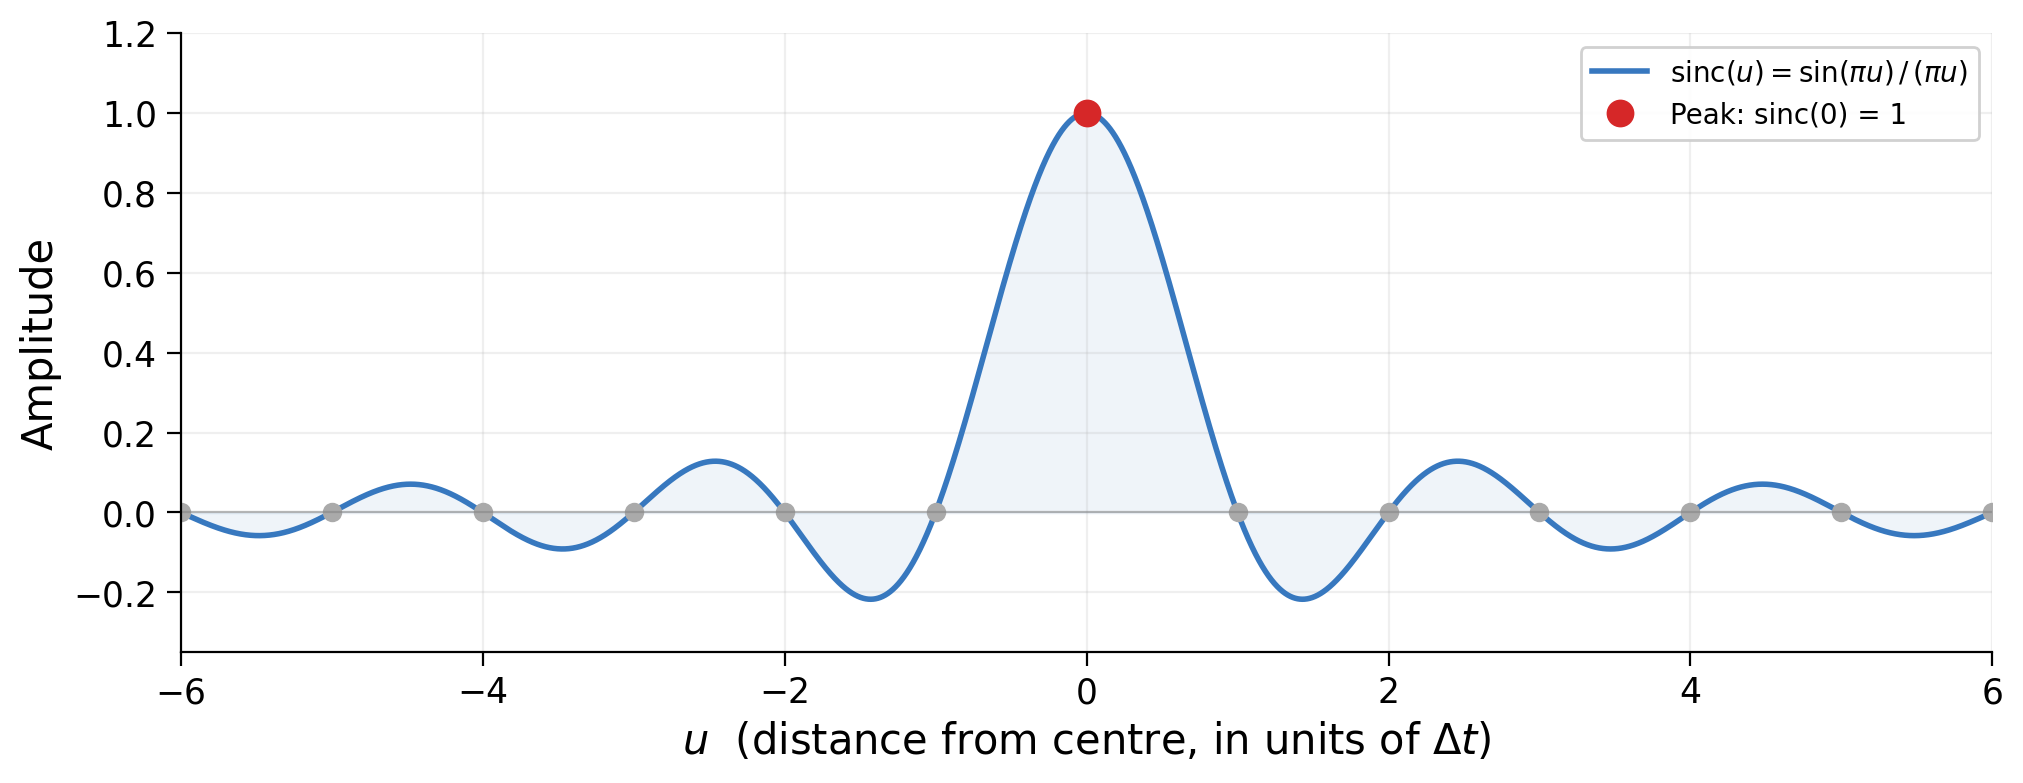

In [18]:
# @markdown Execute after completing the function
# ── test ─────────────────────────────────────────────────────
assert np.isclose(sinc(0),    1.0),  'sinc(0) should be 1'
assert np.isclose(sinc(1),    0.0),  'sinc(1) should be 0'
assert np.isclose(sinc(-1),   0.0),  'sinc(-1) should be 0'
assert np.isclose(sinc(0.5),  2/np.pi), 'sinc(0.5) should be 2/pi'
print('All tests passed ✓')

# ── visualise ─────────────────────────────────────────────────
u        = np.linspace(-6, 6, 10_000)
y        = sinc(u)
integers = np.arange(-6, 7)

fig, ax = plt.subplots(figsize=(10, 3.8), constrained_layout=True)
fig.set_facecolor('white')

ax.plot(u, y, color='#3778bf', lw=2.0, zorder=2,
        label=r'$\mathrm{sinc}(u) = \sin(\pi u)\,/\,(\pi u)$')
ax.fill_between(u, y, alpha=0.08, color='#3778bf')

# zero crossings at nonzero integers
ax.stem(integers[integers != 0],
        sinc(integers[integers != 0]),
        linefmt='#aaaaaa', markerfmt='o', basefmt='none')

# peak
ax.plot(0, 1, 'o', color='#d62728', markersize=9,
        zorder=5, label='Peak: sinc(0) = 1')

ax.axhline(0, color='gray', lw=0.8, alpha=0.5)
ax.set(xlabel='$u$  (distance from centre, in units of $\Delta t$)',
       ylabel='Amplitude',
       xlim=(-6, 6), ylim=(-0.35, 1.2))
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.20)
plt.show()

## Interpolation and reconstruction using sinc function

To reconstruct the signal post hoc at any time point $t$ that was NOT sampled, we *convolve* the sinc function with the discrete samples. We will cover convolution in detail in Tutorial 3, but for now, we can describe the process in words:

- center one sinc function at each sampled time point $n$
- multiply the whole sinc with the sampled signal amplitude at this point $x[n]$, i.e., scale the sinc by $x[n]$
- lastly, sum over all the scaled sinc contributions

$$\hat{x}(t) = \sum_{n} x[n] \cdot \operatorname{sinc}\!\left(\frac{t - n\Delta t}{\Delta t}\right)$$

The argument $\frac{t - n\Delta t}{\Delta t}$ measures how far the evaluation point
$t$ is from sample $n$, in units of the sampling interval $\Delta t$. Each sinc peaks at its own sample and is zero at all others. So you can see straight away, that the reconstructed, continuous signal runs indeed through all sample points.

In [19]:
def reconstruct_sinc(t_samp, y_samp,t_eval):
    """
    Whittaker–Shannon sinc reconstruction.

    Uses the nearest samples on each side of every evaluation
    point — sinc tails beyond that are below one display pixel.

    Parameters
    ----------
    t_samp  : (M,) sample times (total-time axis, full 100 s context)
    y_samp  : (M,) sample values
    t_eval  : (N,) evaluation times (total-time axis)

    Returns
    -------
    y_hat : (N,) reconstructed signal
    """
    ##############################################################

    T = t_samp[1] - t_samp[0]
    # generate a denser grid than the samples, to get the intermediate values
    y_hat = np.zeros(len(t_eval))
    for i, t in enumerate(t_eval):
        diff = (t - t_samp) / T
        y_hat[i] = (y_samp * sinc(diff)).sum()
    return t_eval, y_hat
    #############################################################


# --- test ---
t_samp, y_samp = subsample(_t_total, _sig_sine, fs=20,phase = 0)
t_eval, y_sinc  = reconstruct_sinc(t_samp, y_samp,t_eval )

assert y_sinc.shape == sig_true.shape, 'Sinc output shape mismatch'
print('All reconstruction tests passed ✓')

All reconstruction tests passed ✓


## Interactive Demo 3: Sinc reconstruction

Use the interactive demo below to compare the lollipop, linear, and **sinc reconstruction** at a **fixed** sampling frequency and signal. The true signal is a $5$ Hz sine wave sampled at $15$ Hz.

In [20]:
# @title Helper: plot_reconstruction_w_sinc — run this cell

def subsample(t_total, sig_total, fs, phase):
    step   = max(1, int(round(FS_TRUE / fs)))
    idx    = np.arange(int(np.round(0+phase/2/np.pi*step)), len(t_total), step)
    return t_total[idx], sig_total[idx]

def plot_reconstruction_w_sinc(fs, mode , t_eval,phase):
    t_samp, y_samp = subsample(_t_total, _sig_sine, fs,phase)
    t_v, y_v       = get_one_second_signal_to_visualize(t_samp, y_samp, _start_t)

    fig, axes = plt.subplots(2, 1, figsize=(10, 6),
                             constrained_layout=True, sharex=True)
    fig.set_facecolor('white')

    # top: true + samples
    ax = axes[0]
    ax.plot(t_plot, sig_true, color='#3778bf', lw=1.8,
            alpha=0.85, label='True signal', zorder=2)
    ax.plot(t_v, y_v, 'o', color='#d62728', markersize=5.5,
            zorder=4, label=f'Samples ({len(t_v)} in window)')
    ax.set(ylabel='Amplitude', ylim=(-1.25, 1.25),
           title=f'True signal and samples  (fs = {fs} Hz)')
    ax.legend(fontsize=9, framealpha=0.9, loc='upper right')
    ax.grid(True, alpha=0.20)

    # bottom: reconstruction
    ax = axes[1]
    ax.plot(t_plot, sig_true, color='#3778bf', lw=1.4,
            alpha=0.25, label='True signal (reference)', zorder=1)

    if mode == 'lollipop':
        ax.plot(t_v, y_v, 'o', color='#d62728', markersize=5.5,
                label='Lollipop', zorder=4)
        ax.vlines(t_v, 0, y_v, color='#d62728', lw=1.3, alpha=0.75, zorder=3)

        title = 'Lollipop'

    elif mode == 'linear':

        ax.plot(t_v, y_v, '-o', color='#d62728', markersize=4, zorder=4)
        title = 'Linear - straight lines between samples'


    else:
        t_eval, y_sinc = reconstruct_sinc(t_samp, y_samp,t_eval)
        t_v1, y_v1       = get_one_second_signal_to_visualize(t_eval, y_sinc, _start_t)
        ax.plot(t_v1,y_v1, color='#9467bd', lw=1.8,label='Sinc reconstruction', zorder=3)

        ax.plot(t_v, y_v, 'o', color='#d62728', markersize=4, zorder=4)
        title = 'Sinc — Whittaker–Shannon reconstruction'

    ax.set(xlabel='Time (s)', ylabel='Amplitude',
           ylim=(-1.25, 1.25), title=title)
    ax.legend(fontsize=9, framealpha=0.9, loc='upper right')
    ax.grid(True, alpha=0.20)
    plt.show()

# @markdown Execute to compare reconstruction strategies

@widgets.interact(
    #fs   = widgets.IntSlider(value=15, min=11, max=80, step=1,
    #                         description='fs (Hz):',
    #                         style={'description_width': '70px'},
    #                         layout=widgets.Layout(width='480px')),
    mode = widgets.RadioButtons(
               options=[('Lollipop',                'lollipop'),
                        ('Straight-line connectors', 'linear'),
                        ('Sinc reconstruction',      'sinc')
                        ],
               value='lollipop',
               description='Method:',
               style={'description_width': '70px'})
)
def visualize_reconstruction(mode='lollipop'):
    plot_reconstruction_w_sinc(fs = 15, mode = mode , t_eval = t_eval,phase=0)

interactive(children=(RadioButtons(description='Method:', options=(('Lollipop', 'lollipop'), ('Straight-line c…

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Demo_3_Reconstruction")

---

# Section 4: Sampling theorem and aliasing

*Estimated timing to here from start of tutorial: 30 min*

You have confirmed above that sinc reconstruction was able to reconstruct the sine wave *perfectly* from 3 sample points per period.

In this final section, we ask: **how low can the sampling frequency be before even the ideal sinc reconstruction fails?**

## Interactive Demo 4: Find the frequency at which reconstruction fails

This demo below uses sinc as the reconstruction method and lets you vary $f_s$. There are two signals to explore:

1. **Sine wave** : a pure $15$ Hz oscillation. Watch the sinc reconstruction degrade as you approach then cross a critical threshold.

2. **Transient response** : a brief oscillatory burst (like a stimulus-locked high-gamma response).


**Your task:** for each signal, find the lowest $f_s$ at which sinc reconstruction still accurately recovers the signal. Write those two numbers down before reading the next Section.

In [21]:
# @title True Signal Generation — run this cell

def reconstruction_error(sig_true, sig_recon):
    """Compute RMSE between true and reconstructed signal.

    Parameters
    ----------
    sig_true  : (N,) ground truth signal
    sig_recon : (N,) reconstructed signal

    Returns
    -------
    float : root mean square error
    """
    ##############################################################################
    return np.sqrt(np.mean((sig_true - sig_recon) ** 2))
    ##############################################################################


FS_TRUE   = 10_000.0   # dense axis, treated as continuous
F_SIGNAL  = 15.0        # Hz — sine wave frequency
DURATION  = 1.0        # seconds — displayed window
TOTAL_DUR = 100.0      # seconds — full context for sinc reconstruction

# ── sine signal ──────────────────────────────────────────────
_N          = int(FS_TRUE * TOTAL_DUR)
_t_total    = np.linspace(0, TOTAL_DUR, _N, endpoint=False)
_sig_sine   = np.sin(2 * np.pi * F_SIGNAL * _t_total)

_start_t    = (TOTAL_DUR - DURATION) / 2
_mask       = (_t_total >= _start_t) & (_t_total < _start_t + DURATION)
t_eval      = _t_total[_mask]          # total-time axis — used in sinc, never shifted
t_plot      = t_eval - _start_t        # 0–1 s axis — used only for plotting
sig_true    = _sig_sine[_mask]         # ground truth: same array as _sig_sine

# ── transient evoked signal ───────────────────────────────────
F_TRANSIENT  = 30.0    # Hz — carrier frequency of the transient
_center      = TOTAL_DUR / 2
_sigma       = 0.1
_envelope    = np.exp(-((_t_total - _center)**2) / (2 * _sigma**2))
_sig_trans   = _envelope * np.sin(2 * np.pi * F_TRANSIENT * _t_total)

sig_transient = _sig_trans[_mask]

print(f'Sine signal:      {len(sig_true)} samples in display window')
print(f'Transient signal: peak = {sig_transient.max():.3f}, '
      f'carrier = {F_TRANSIENT} Hz')

Sine signal:      10000 samples in display window
Transient signal: peak = 0.997, carrier = 30.0 Hz


In [22]:
# @title Helper: plot_sinc_explorer — run this cell

def plot_sinc_explorer(fs, signal_type , t_eval,phase):
    if signal_type == 'sine':
        sig_full  = _sig_sine
        sig_disp  = sig_true
        f_label   = f'{F_SIGNAL} Hz sine'
    else:
        sig_full  = _sig_trans
        sig_disp  = sig_transient

        f_label   = f'Transient signal with maximum power up to ~34Hz'

    t_samp, y_samp = subsample(_t_total, sig_full, fs,phase)
    t_eval, y_sinc = reconstruct_sinc(t_samp, y_samp, t_eval)
    t_v, y_v       =  get_one_second_signal_to_visualize(t_samp, y_samp, _start_t)
    rmse           = reconstruction_error(sig_disp, y_sinc)

    fig = plt.figure(figsize=(10, 5), constrained_layout=True)
    fig.set_facecolor('white')
    gs  = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, 1])

    # ── top: true + samples ───────────────────────────────────
    ax0 = fig.add_subplot(gs[0])
    ax0.plot(t_plot, sig_disp, color='#3778bf', lw=1.8,
             alpha=0.85, label='True signal', zorder=2)
    ax0.plot(t_v, y_v, 'o', color='#d62728', markersize=5,
             zorder=4, label=f'Samples ({len(t_v)})')
    ax0.set(ylabel='Amplitude', ylim=(-1.25, 1.25),
            title=f'{f_label}')
    ax0.legend(fontsize=9, loc='upper right', framealpha=0.9)
    ax0.grid(True, alpha=0.20)

    # ── middle: sinc reconstruction ──────────────────────────
    ax1 = fig.add_subplot(gs[1], sharex=ax0)
    ax1.plot(t_plot, sig_disp, color='#3778bf', lw=1.4,
             alpha=0.25, label='True signal (reference)', zorder=1)
    ax1.plot(t_plot, y_sinc, color='#9467bd', lw=1.8,
             label='Sinc reconstruction', zorder=3)
    ax1.plot(t_v, y_v, 'o', color='#d62728', markersize=4, zorder=4)
    ax1.text(0.99, 0.95, f'RMSE = {rmse:.4f}',
             transform=ax1.transAxes, fontsize=10,
             ha='right', va='top',
             color='#27ae60' if rmse < 0.05 else '#c0392b',
             fontweight='bold')
    ax1.set(ylabel='Amplitude', ylim=(-1.25, 1.25),
            title='Sinc reconstruction')
    ax1.legend(fontsize=9, loc='upper right', framealpha=0.9)
    ax1.grid(True, alpha=0.20)
    print(f'RMSE of sinc reconstruction: {rmse:.4f}')
    plt.show()

# @markdown Execute to explore the effect of sampling frequency

@widgets.interact(
    fs = widgets.IntSlider(value=50, min=5, max=100, step=1,
                           description='fs (Hz):',
                           style={'description_width': '100px'},
                           layout=widgets.Layout(width='700px')),
    signal_type = widgets.RadioButtons(
                      options=[('Sine wave',          'sine'),
                               (f'Transient response ({F_TRANSIENT} Hz/{int(_sigma*1000)}ms)', 'transient')],
                      value='sine',
                      description='Signal:',
                      style={'description_width': '500px'})
)
def visualize_sinc_explorer(fs=30, signal_type='sine'):
    plot_sinc_explorer(fs, signal_type , t_eval,phase=0)

interactive(children=(IntSlider(value=50, description='fs (Hz):', layout=Layout(width='700px'), min=5, style=S…

In [ ]:
# @title Video 4: The Nyquist–Shannon sampling theorem

from ipywidgets import widgets
from IPython.display import YouTubeVideo
from IPython.display import IFrame
from IPython.display import display


class PlayVideo(IFrame):
  def __init__(self, id, source, page=1, width=400, height=300, **kwargs):
    self.id = id
    if source == 'Bilibili':
      src = f'https://player.bilibili.com/player.html?bvid={id}&page={page}'
    elif source == 'Osf':
      src = f'https://mfr.ca-1.osf.io/render?url=https://osf.io/download/{id}/?direct%26mode=render'
    super(PlayVideo, self).__init__(src, width, height, **kwargs)


def display_videos(video_ids, W=400, H=300, fs=1):
  tab_contents = []
  for i, video_id in enumerate(video_ids):
    out = widgets.Output()
    with out:
      if video_ids[i][0] == 'Youtube':
        video = YouTubeVideo(id=video_ids[i][1], width=W,
                             height=H, fs=fs, rel=0)
        print(f'Video available at https://youtube.com/watch?v={video.id}')
      else:
        video = PlayVideo(id=video_ids[i][1], source=video_ids[i][0], width=W,
                          height=H, fs=fs, autoplay=False)
        if video_ids[i][0] == 'Bilibili':
          print(f'Video available at https://www.bilibili.com/video/{video.id}')
        elif video_ids[i][0] == 'Osf':
          print(f'Video available at https://osf.io/{video.id}')
      display(video)
    tab_contents.append(out)
  return tab_contents

video_ids = [('Youtube', 'WlCP9qknZcE'), ('Bilibili', 'BV1JCMp6DEnE')]
tab_contents = display_videos(video_ids, W=854, H=480)
tabs = widgets.Tab()
tabs.children = tab_contents
for i in range(len(tab_contents)):
  tabs.set_title(i, video_ids[i][0])
display(tabs)

The threshold below which reconstruction fails is given by the following theorem:

> **Nyquist–Shannon sampling theorem:** A continuous bandlimited signal
> with highest frequency $f_{\max}$ can be perfectly reconstructed from
> its samples if and only if the sampling frequency satisfies:
>
> $$\boxed{f_s > 2\, f_{\max}}$$

The value $f_N = f_s / 2$ is called the **Nyquist frequency**, the highest frequency your recording system can faithfully capture.

For the two signals you explored:

| Signal | $f_{\max}$ | Minimum $f_s$ |
|---|---|---|
| Sine wave |  $ 15$ Hz | $> 30$ Hz |
| Transient response | $\approx 34$ Hz | $> 68$ Hz |

Does that match the thresholds you found with the slider?

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Demo_4_Nyquist")

---

*Estimated timing to here from start of tutorial: 40 min*


When the Nyquist criterion, i.e., $f_s \gt 2 f_{\text{max}}$, is not satisfied, the signal appears in the reconstruction **at a wrong, apparent frequency**, usually a lower one.

This is called **aliasing**.

Now you can understand the earlier statement that a signal can be fully reconstructed, provided that the sample points were sufficiently closely spaced.

## Why does aliasing happen?

A sampler only records one number per interval $1/f_s$. If the original signal (or the fastest component in a signal) oscillates with $f_{\text{signal}} > f_s / 2$, the sinc reconstruction creates a signal with a lower frequency that passes through all the sample points.

You can nicely see this in the demo when you choose a sampling frequency of, for example, 24 Hz: with $f_s = 24$, the fastest, just trackable oscillation is limited to below 12 Hz. The original 15 Hz signal is 3 Hz **above** the limit, which is then reconstructed as a frequency that is 3 Hz **below** that limit. Count the periods and you will find exactly 9 in the 1 second of data.

### At which frequency does the alias appear?

Each integer multiple of the sampling frequency $f_s$ acts like a mirror. The alias lands at the distance from $f_{\text{true signal}}$ to its nearest such mirror:

$$f_{\text{alias}} = \left| f_{\text{true signal}} - \operatorname{round}
\!\left(\frac{f_{\text{true signal}}}{f_s}\right) \cdot f_s \right|$$

### Worked example

A $30$ Hz true signal sampled at $f_s = 40$ Hz (Nyquist $= 20$ Hz):

1. Nearest mirror: $\operatorname{round}(30/40) \times 40 = 1 \times 40 = 40$ Hz
2. Distance to mirror: $|30 - 40| = 10$ Hz

The $30$ Hz true oscillation appears as $10$ Hz oscillation
in your sampled data.

---

A really classic and fun demonstration of aliasing is the [slow or backward spinning rotor effect](https://www.youtube.com/watch?v=jWIcVP6GRfw), where the frame rate of the camera (sampling frequency) is lower than the frequencies of the signal itself!

## Coding Exercise 4: Compute Aliased Frequency

In [23]:
def compute_aliased_frequency(signal_freq, sampling_freq):
    """Compute the apparent frequency after aliasing.

    Parameters
    ----------
    signal_freq   : float, true signal frequency (Hz)
    sampling_freq : float, sampling frequency (Hz)

    Returns
    -------
    float : apparent frequency (Hz). Returns signal_freq if no aliasing.
    """

    if sampling_freq >= 2 * signal_freq:
        # above Nyquist — no aliasing
        return sampling_freq

    f_alias = np.abs(np.round(signal_freq / sampling_freq) * sampling_freq - signal_freq)
    return f_alias

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content/tree/main/tutorials/W2D2_SignalProcessing/solutions/W2D2_Tutorial1_Solution_0751f00a.py)

In [24]:
# @markdown Execute after completing the function
cases = [(5, 8, 3.0), (5, 7, 2.0), (30, 40, 10.0), (5, 20, 5.0)]
for f, fs, expected in cases:
    result = compute_aliased_frequency(f, fs)
    status = '✓' if abs(result - expected) < 1e-9 else '✗'
    print(f'{status}  f={f} Hz, fs={fs} Hz → alias={result:.1f} Hz '
          f'(expected {expected:.1f} Hz)')

✓  f=5 Hz, fs=8 Hz → alias=3.0 Hz (expected 3.0 Hz)
✓  f=5 Hz, fs=7 Hz → alias=2.0 Hz (expected 2.0 Hz)
✓  f=30 Hz, fs=40 Hz → alias=10.0 Hz (expected 10.0 Hz)
✗  f=5 Hz, fs=20 Hz → alias=20.0 Hz (expected 5.0 Hz)


## Interactive Demo 5: Visualize aliasing frequency

In [25]:
def plot_aliasing(signal_freq, fs, phase):

    # ── build 100s context signal ─────────────────────────────
    N_loc        = int(FS_TRUE * TOTAL_DUR)
    t_total_loc  = np.linspace(0, TOTAL_DUR, N_loc, endpoint=False)
    sig_loc      = np.sin(2 * np.pi * signal_freq * t_total_loc)

    start_t_loc  = (TOTAL_DUR - DURATION) / 2
    mask_loc     = (t_total_loc >= start_t_loc) & (t_total_loc < start_t_loc + DURATION)
    t_eval_loc   = t_total_loc[mask_loc]
    t_plot_loc   = t_eval_loc - start_t_loc
    sig_true_loc = sig_loc[mask_loc]

    # ── subsample ─────────────────────────────────────────────
    t_samp_loc, y_samp_loc = subsample(t_total_loc, sig_loc, fs,phase)
    in_win  = (t_samp_loc >= start_t_loc) & (t_samp_loc < start_t_loc + DURATION)
    t_v_loc = t_samp_loc[in_win] - start_t_loc
    y_v_loc = y_samp_loc[in_win]

    # ── sinc reconstruct ──────────────────────────────────────
    t_eval, y_sinc = reconstruct_sinc(t_samp_loc, y_samp_loc, t_eval_loc)

    # ── aliasing info ─────────────────────────────────────────
    nyquist     = fs / 2
    aliased     = signal_freq >= nyquist
    f_alias     = compute_aliased_frequency(signal_freq, fs)
    recon_color = '#c0392b' if aliased else '#27ae60'
    status      = (f'⚠  Aliasing — {signal_freq} Hz appears as {f_alias:.1f} Hz'
                   if aliased else
                   f'✓  No aliasing  (Nyquist = {nyquist:.1f} Hz > {signal_freq} Hz)')

    # ── plot ──────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    fig.set_facecolor('white')

    ax.plot(t_plot_loc, sig_true_loc,
            color='#3778bf', lw=1.8, alpha=0.85,
            label=f'True signal ({signal_freq} Hz)', zorder=2)
    ax.plot(t_plot_loc, y_sinc,
            color=recon_color, lw=1.8,
            label='Sinc reconstruction', zorder=3)
    ax.plot(t_v_loc, y_v_loc, 'o',
            color='#d62728', markersize=6,
            label=f'Samples ({len(t_v_loc)})', zorder=5)

    ax.text(0.99, 0.97, status,
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            color=recon_color, ha='right', va='top')
    ax.set(xlabel='Time (s)', ylabel='Amplitude',
           ylim=(-1.25, 1.25),
           title=f'Signal = {signal_freq} Hz   '
                 f'fs = {fs} Hz   '
                 f'Nyquist = {nyquist:.1f} Hz')
    ax.legend(fontsize=9, framealpha=0.9, loc='upper left')
    ax.grid(True, alpha=0.20)
    plt.show()


# @markdown Execute to visualise aliasing

@widgets.interact(
    signal_freq = widgets.IntSlider(value=15, min=2, max=15, step=1,
                                    description='Signal (Hz):',
                                    style={'description_width': '100px'},
                                    layout=widgets.Layout(width='480px')),
    fs          = widgets.IntSlider(value=30, min=3, max=50, step=1,
                                    description='fs (Hz):',
                                    style={'description_width': '100px'},
                                    layout=widgets.Layout(width='480px')),
    phase       = widgets.FloatSlider(value=np.pi, min=0, max=2*np.pi, step=np.pi/25,
                                    description='Phase (rad):',
                                    style={'description_width': '100px'},
                                    layout=widgets.Layout(width='480px'))
)
def visualize_aliasing(signal_freq=5, fs=40, phase = 0):
    plot_aliasing(signal_freq, fs, phase)

interactive(children=(IntSlider(value=15, description='Signal (Hz):', layout=Layout(width='480px'), max=15, mi…

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Demo_5_Aliasing")

---

# Summary

*Estimated timing of tutorial: 45 min*

---

**Sampling**:

A continuous signal $x(t)$ is reduced to a discrete sequence by recording its value at regular intervals:

$$x[n] = x(n\Delta t), \qquad \Delta t = \frac{1}{f_s}$$

- **Sampling frequency** $f_s$ (Hz) sets how many measurements are taken per second.
- The step size in samples is $k = \text{round}(f_{s,\text{true}} / f_s)$; every $k$-th index of the dense array is retained.
- Higher $f_s$ preserves more detail but increases data volume and storage cost.

---

**Reconstruction**

Given discrete samples $x[n]$, three strategies estimate the signal between sample points:

| Strategy | How it works | Limitation |
|---|---|---|
| **Lollipop** | Show only sample values as vertical stems | No information about between-sample values |
| **Linear interpolation** | Connect adjacent samples with straight lines | Assumes constant rate of change; distorts curved signals |
| **Sinc reconstruction** | Sum scaled sinc kernels centred at each sample | Optimal — requires samples above Nyquist rate |

**Sinc interpolation formula:**

$$\hat{x}(t) = \sum_{n} x[n] \cdot \operatorname{sinc}\!\left(\frac{t - n\Delta t}{\Delta t}\right), \qquad \operatorname{sinc}(u) = \frac{\sin(\pi u)}{\pi u}$$

Key properties of the sinc kernel:
- Peak of 1 at $u = 0$ (the sample instant); zero at all other integers $u = \pm1, \pm2, \ldots$
- Contributions from different samples do not interfere at any sample point.
- Sinc reconstruction is the unique strategy that perfectly recovers any bandlimited signal sampled above the Nyquist rate.

---
**Effect of Sampling Frequency — The Nyquist–Shannon Theorem**

Sinc reconstruction can only succeed if the sampling frequency is high enough relative to the signal's highest frequency content.

> **Nyquist–Shannon theorem:** A bandlimited signal with highest frequency $f_{\max}$ can be perfectly reconstructed if and only if:
> $$\boxed{f_s > 2\,f_{\max}}$$

- $f_N = f_s / 2$ is the **Nyquist frequency** — the highest frequency the recording system can faithfully capture.
- Sampling below the Nyquist rate causes irreversible information loss; no reconstruction method can recover the original signal.

---

**Aliasing**

If $f_{\text{signal}} \geq f_s/2$, the sampler records at most two points per cycle. Successive samples accidentally trace out a **slower, fictitious oscillation** — the alias.

**Alias frequency formula:**

$$f_{\text{alias}} = \left| f_{\text{signal}} - \operatorname{round}\!\left(\frac{f_{\text{signal}}}{f_s}\right) \cdot f_s \right|$$

- Each integer multiple of $f_s$ acts as a mirror; the alias lands at the distance between $f_{\text{signal}}$ and its nearest mirror.
- The alias is indistinguishable from a true signal at that frequency — aliasing cannot be corrected after the fact.

**Practical implication:** Always make sure that the signal to be digitized contains no signal components at frequencies above $f_s/2$. This is done by a low-pass filter, as you will see in Tutorial 3. This filter is often called an anti-aliasing filter.

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Summary")